In [202]:
# ================================
#  matplotlib + LaTeX header  (paste at the top of a notebook)
#  Document assumptions: \documentclass[12pt]{article}, geometry 2cm margins
#  -> \textwidth = 21 - 2 - 2 = 17 cm
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import RWTHColors

import re
import csv
import sys,os

# --- document-level constants ------------------------------------------------
DOC_FONTSIZE_PT = 12          # must match \documentclass[12pt]
TEXTWIDTH_CM    = 17.0        # must match \textwidth
DEFAULT_RATIO   = 1 / 1.618   # golden ratio, height / width per panel
GAP_CM          = 0.3         # gap reserved for \hfill between side-by-side figures

CM_PER_INCH  = 2.54
TEXTWIDTH_IN = TEXTWIDTH_CM / CM_PER_INCH

def figsize(fraction=1.0, n_per_row=1, ratio=DEFAULT_RATIO, height_in=None):
    """
    Figure size in inches.

    fraction   : how much of \\textwidth the WHOLE figure occupies.
    n_per_row  : number of panels (axes) sitting horizontally in the figure.
    ratio      : height / width APPLIED PER PANEL
    height_in  : explicit height in inches; overrides `ratio`.
    """
    total_w_cm = fraction * TEXTWIDTH_CM
    panel_w_cm = (total_w_cm - (n_per_row - 1) * GAP_CM) / n_per_row
    w = total_w_cm / CM_PER_INCH
    h = panel_w_cm * ratio / CM_PER_INCH
    return (w, h)

# --- rcParams (set once per notebook) ---------------------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",

    # All text locked to document base size — never change between figures.
    "font.size":        DOC_FONTSIZE_PT,
    "axes.labelsize":   DOC_FONTSIZE_PT,
    "axes.titlesize":   DOC_FONTSIZE_PT,
    "legend.fontsize":  DOC_FONTSIZE_PT,
    "xtick.labelsize":  DOC_FONTSIZE_PT,
    "ytick.labelsize":  DOC_FONTSIZE_PT,

    "axes.linewidth":   0.5,
    "grid.linewidth":   0.2,
    "lines.linewidth":  1.0,
    "lines.markersize": 3,
    "patch.linewidth":  0.5,

    # Manage spacing INSIDE the fixed figure box; do NOT crop on save.
    "figure.constrained_layout.use": True,
    "savefig.bbox":       "standard",
    "savefig.pad_inches": 0.0,

    "figure.dpi":     150,
    "savefig.dpi":    300,
    "savefig.format": "pdf",
})
plt.style.use("rwth")

fig_path = "/Users/fsteinme/dev/papers/2026_CPIPM08_MB_IPM/figures/"

In [203]:
def to12(arr):
    return np.abs(arr[:12]) + np.abs(arr[12:])

In [204]:
!ls | grep tension

config_tension.toml
ex_single_step_uniaxial_tension.py
ex_uniaxial_tension.py
out_tension_000


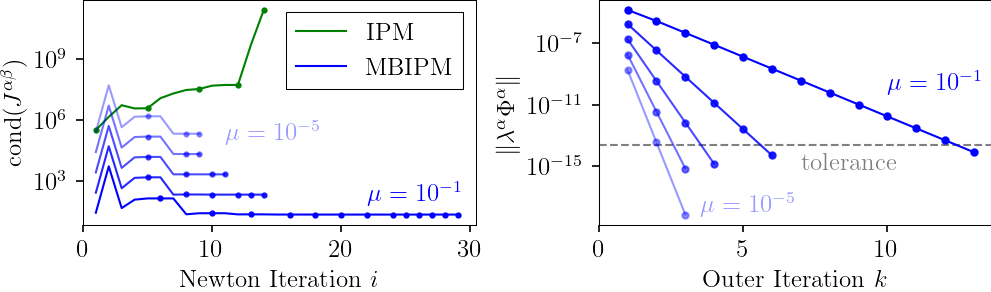

In [211]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=figsize(1.0, n_per_row=2))
df_IPM = pd.read_csv(base_pth + "out_single_IPM/trace_IPM_classic.csv")
mu_min = 1
mu_max = 6

mu_range = [i for i in range(mu_min,mu_max)]
alpha_range = np.linspace(1.0,0.4,len(mu_range))

#======================================
# Conditioning of Primal Dual System
#======================================
df_IPM = pd.read_csv(base_pth + "out_single_IPM/trace_IPM_classic.csv")
ax1.plot(df_IPM["iter"], df_IPM["cond_solved"], color = "green", label="IPM")
#plot dots for barrier decrease
s_iter = df_IPM.groupby("k")["iter"].first()
s_barr = df_IPM.groupby("k")["cond_solved"].first()
ax1.plot(s_iter.values, s_barr.values, ".", color = "green", ms = 4)

for i,alpha in zip(mu_range, alpha_range):
    mu = 10**i
    pth = f"out_single_mu_1e{i}/"
    df = pd.read_csv(base_pth + pth + "trace_MB-IPM-classic.csv")
    ax1.plot(df["iter"], df["cond_solved"], color = "blue", alpha = alpha)

    #plot dots for outer iterations
    s_iter = df.groupby("k")["iter"].last()
    s_barr = df.groupby("k")["cond_solved"].last()
    ax1.plot(s_iter.values, s_barr.values, ".", color = "blue", ms = 4, alpha = alpha)

ax1.plot([],[], color="blue", label = "MBIPM")

ax1.set_xlim(0,)
ax1.set_yscale('log')

ax1.set_xlabel(r"Newton Iteration $i$")
ax1.set_ylabel(r"$\operatorname{cond}(J^{\alpha\beta})$")

ax1.text(11, 10**5, r'$\mu=10^{-5}$', fontsize=12, color='blue', alpha = 0.4)
ax1.text(22, 10**2, r'$\mu=10^{-1}$', fontsize=12, color='blue', alpha = 1.0)

ax1.legend(fancybox=False, edgecolor="black", framealpha=1.0, shadow=False, fontsize=12)

#======================================
# Outer Convergence
#======================================

# tolerance line
ax2.axhline(y=10**(-13.6), color='grey', linestyle='--', linewidth=1)

s = df_IPM.groupby("k")["compl_gap"].last() 
#ax2.plot(s.index+1, s.values, "-o", color="green")

for i,alpha in zip(mu_range, alpha_range):
    mu = 10**i
    pth = f"out_single_mu_1e{i}/"
    df = pd.read_csv(base_pth + pth + "trace_MB-IPM-classic.csv")
    s = df.groupby("k")["compl_gap"].last() 
    ax2.plot(s.index, s.values, "-o", color="blue", alpha = alpha)


ax2.set_xlim(0,)
ax2.set_yscale('log')

ax2.text(10, 10**(-10), r'$\mu=10^{-1}$', fontsize=12, color='blue', alpha = 1.0)
ax2.text(3.5, 10**(-18), r'$\mu=10^{-5}$', fontsize=12, color='blue', alpha = 0.4)


ax2.text(7, 10**(-15.2), r'tolerance', fontsize=12, color='grey',)

ax2.set_ylabel(r"$\|\lambda^\alpha\Phi^\alpha\|$")
ax2.set_xlabel(r"Outer Iteration $k$")

fig.savefig(fig_path + "SS_cond_conv.pdf",bbox_inches="tight", pad_inches=0.00, dpi=600)

plt.show()

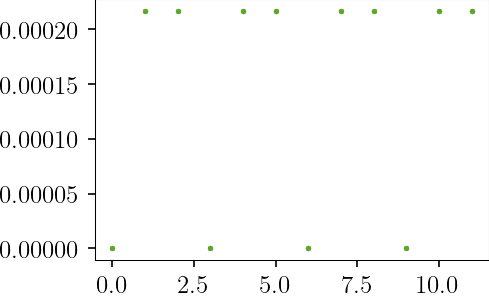

In [40]:
fig,ax = plt.subplots(figsize = figsize(0.5))
plt.plot(AL_gam,".")
plt.plot(IPM_gam,".")
plt.plot(MBIPM_gam,".")

In [215]:
import sys
sys.path.append('../cp_matroutines')
import cp_base as CP

In [223]:
M = CP.Material()

fac = 2*np.sqrt(6)

M.Za[5] * fac

array([[ 2.,  0., -1.],
       [ 0., -2., -1.],
       [-1., -1.,  0.]])

In [ ]:
/Users/fsteinme/dev/11_SS_CP_IPM_VP_Python/examples/FIG - paper08 - Newton System.ipynb